In [17]:
import pandas as pd

df = pd.read_csv("table1_historical.csv")

df.head()

,flight_id,date,origin,destination,distance,flight_time,route_popularity,aircraft,seat_capacity,departure_hour,...,weather_score,fuel_price,economic_index,booking_stage,fare_class,fare_capacity,price,competitor_price,price_ratio,demand
0,F00001,2022-11-24,DFW,LAS,1055,2.7,1.08,A320,180,6,...,0.86,102.23,104.04,Early,Economy,135,239.30,264.96,0.903,34
1,F00001,2022-11-24,DFW,LAS,1055,2.7,1.08,A320,180,6,...,0.86,102.23,104.04,Middle,Economy,135,211.45,173.92,1.216,45
2,F00001,2022-11-24,DFW,LAS,1055,2.7,1.08,A320,180,6,...,0.86,102.23,104.04,Final,Economy,135,375.35,414.63,0.905,5
3,F00001,2022-11-24,DFW,LAS,1055,2.7,1.08,A320,180,6,...,0.86,102.23,104.04,Early,Premium,27,612.98,647.47,0.947,3
4,F00001,2022-11-24,DFW,LAS,1055,2.7,1.08,A320,180,6,...,0.86,102.23,104.04,Middle,Premium,27,416.42,477.40,0.872,16


In [18]:
df = df[df["fare_class"] == "Premium"]

In [19]:
df = df.drop(
    columns=[
        
        'flight_id',
        'origin', #same for all
        'fare_class', #same for all
        'date'
        
    ]
)

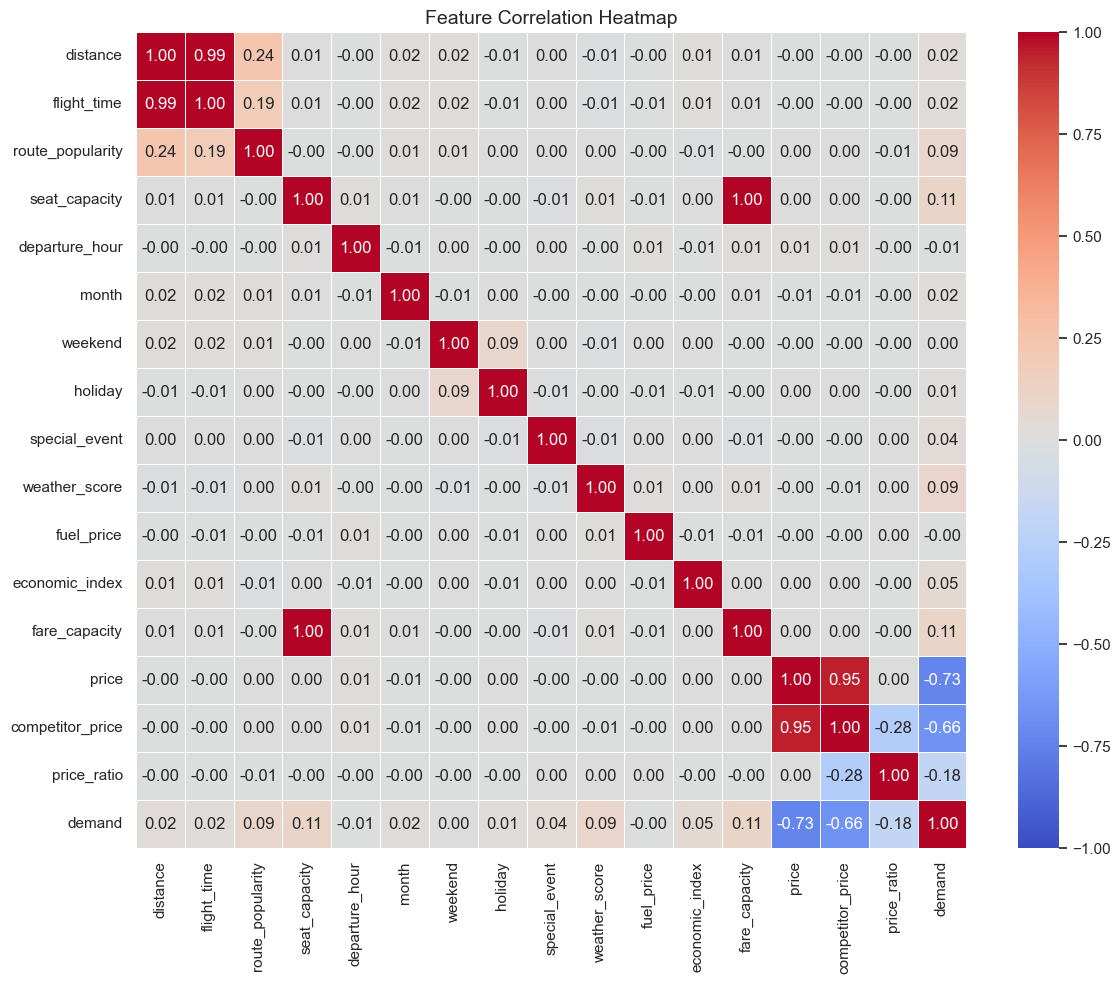

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns
numeric_df = df.select_dtypes(include=["number"])

# Compute correlation matrix
corr = numeric_df.corr()

# Plot correlation heatmap focused on target or full matrix
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,  # Display correlation values in cells
    fmt=".2f",  # Format values to 2 decimal places
    cmap="coolwarm",  # Color map (red = positive, blue = negative)
    vmin=-1,
    vmax=1,  # Set colorbar range
    center=0,
    linewidths=0.5,
)

plt.title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

In [21]:
print(df.isnull().values.any())  # Returns True if any missing value exists, else False

# Count missing values per column
print(df.isnull().sum())

False
destination         0
distance            0
flight_time         0
route_popularity    0
aircraft            0
seat_capacity       0
departure_hour      0
month               0
day_of_week         0
weekend             0
holiday             0
season              0
special_event       0
weather_score       0
fuel_price          0
economic_index      0
booking_stage       0
fare_capacity       0
price               0
competitor_price    0
price_ratio         0
demand              0
dtype: int64


In [22]:
from sklearn.model_selection import train_test_split

X = df.drop('demand', axis=1)  # Features
y = df['demand']               # Target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Check the shape of the splits
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (48000, 21)
X_test shape: (12000, 21)
y_train shape: (48000,)
y_test shape: (12000,)


In [23]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 60000 entries, 3 to 179996
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   destination       60000 non-null  object 
 1   distance          60000 non-null  int64  
 2   flight_time       60000 non-null  float64
 3   route_popularity  60000 non-null  float64
 4   aircraft          60000 non-null  object 
 5   seat_capacity     60000 non-null  int64  
 6   departure_hour    60000 non-null  int64  
 7   month             60000 non-null  int64  
 8   day_of_week       60000 non-null  object 
 9   weekend           60000 non-null  int64  
 10  holiday           60000 non-null  int64  
 11  season            60000 non-null  object 
 12  special_event     60000 non-null  int64  
 13  weather_score     60000 non-null  float64
 14  fuel_price        60000 non-null  float64
 15  economic_index    60000 non-null  float64
 16  booking_stage     60000 non-null  object 
 1

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 1. Identify Categorical and Numerical Columns
categorical_cols = ["destination", "aircraft", "season", "day_of_week", "booking_stage"]
numerical_cols = [
    col
    for col in X.columns
    if col not in categorical_cols
]

# 2. Define the Preprocessing Pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_cols,
        ),
    ]
)

# 3. Fit and Transform on Train Data, Transform ONLY on Test Data
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

print("X_train processed shape:", X_train_scaled.shape)
print("X_test processed shape:", X_test_scaled.shape)

X_train processed shape: (48000, 43)
X_test processed shape: (12000, 43)


In [25]:
import numpy as np
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from xgboost import XGBRegressor


def evaluate_predictions(y_true, y_pred, model_name="Model"):
    """Calculates R2, RMSE, and MAE metrics."""
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    return {"Model": model_name, "R2 Score": r2, "RMSE": rmse, "MAE": mae}



# HYPERPARAMETER SEARCH SPACES

# Random Forest Grid
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
}

# XGBoost Grid
xgb_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 6, 9, 12],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
}

# CatBoost Grid
cb_param_grid = {
    "iterations": [200, 400, 600],
    "depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "l2_leaf_reg": [1, 3, 5, 7],
}



# MODEL TUNING WITH RANDOMIZEDSEARCHCV

models_to_tune = [
    (
        "Random Forest",
        RandomForestRegressor(random_state=42, n_jobs=-1),
        rf_param_grid,
    ),
    (
        "XGBoost",
        XGBRegressor(random_state=42, n_jobs=-1, objective="reg:squarederror"),
        xgb_param_grid,
    ),
    (
        "CatBoost",
        CatBoostRegressor(random_state=42, verbose=0),
        cb_param_grid,
    ),
]

best_models = {}
results = []

print("Starting Hyperparameter Tuning...\n" + "-" * 40)

for name, model, grid in models_to_tune:
    print(f"Tuning {name}...")

    # Set up Randomized Search (5-fold cross validation, 10 random trials)
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=grid,
        n_iter=10,  # Increase to 20+ for deeper search if time permits
        scoring="neg_root_mean_squared_error",
        cv=5,
        random_state=42,
        n_jobs=-1,
    )

    search.fit(X_train_scaled, y_train)

    # Store best estimator
    best_model = search.best_estimator_
    best_models[name] = best_model

    # Evaluate on held-out TEST set
    y_pred = best_model.predict(X_test_scaled)
    metrics = evaluate_predictions(y_test, y_pred, model_name=f"{name} (Tuned)")
    results.append(metrics)

    print(f"Best Parameters for {name}: {search.best_params_}\n")


#  METRICS COMPARISON SUMMARY

results_df = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)
print("=" * 60)
print("FINAL TEST SET PERFORMANCE COMPARISON")
print("=" * 60)
print(results_df.to_string(index=False))

Starting Hyperparameter Tuning...
----------------------------------------
Tuning Random Forest...
Best Parameters for Random Forest: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 20}

Tuning XGBoost...
Best Parameters for XGBoost: {'subsample': 0.9, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 1.0}

Tuning CatBoost...
Best Parameters for CatBoost: {'learning_rate': 0.05, 'l2_leaf_reg': 1, 'iterations': 600, 'depth': 8}

FINAL TEST SET PERFORMANCE COMPARISON
                Model  R2 Score     RMSE      MAE
     CatBoost (Tuned)  0.987800 0.628878 0.463116
      XGBoost (Tuned)  0.986423 0.663432 0.484436
Random Forest (Tuned)  0.977858 0.847228 0.575351


In [26]:
import joblib

# 1. Get tuned CatBoost model from the best_models dictionary
best_catboost_model = best_models["CatBoost"]

# 2. Save the trained CatBoost model
joblib.dump(best_catboost_model, "demand_forecasting_premium_model.joblib")
print("CatBoost model successfully saved to 'demand_forecasting_premium_model.joblib'")

# 3. CRITICAL: Save the preprocessor pipeline (StandardScaler + OneHotEncoder)
joblib.dump(preprocessor, "preprocessor_pipeline_demand_premium.joblib")
print(
    "Preprocessor pipeline successfully saved to 'preprocessor_pipeline_demand_premium.joblib'"
)

CatBoost model successfully saved to 'demand_forecasting_premium_model.joblib'
Preprocessor pipeline successfully saved to 'preprocessor_pipeline_demand_premium.joblib'


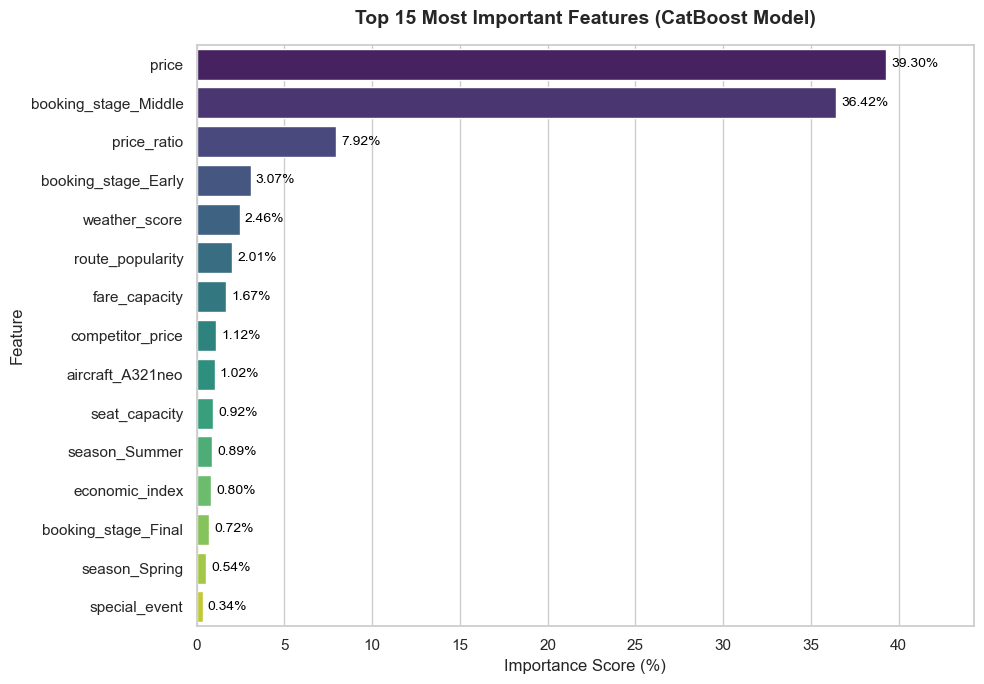

In [27]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# 1. Get feature names generated by ColumnTransformer (StandardScaler + OneHotEncoder)
feature_names = preprocessor.get_feature_names_out()

# Clean up feature names for cleaner chart labels (removes 'num__' and 'cat__' prefixes)
clean_feature_names = [
    f.replace("num__", "").replace("cat__", "") for f in feature_names
]

# 2. Extract feature importance scores from the best CatBoost model
catboost_model = best_models["CatBoost"]
importances = catboost_model.get_feature_importance()

# 3. Combine into a Pandas DataFrame & Sort
importance_df = pd.DataFrame(
    {"Feature": clean_feature_names, "Importance": importances}
).sort_values(by="Importance", ascending=False)

# 4. Filter Top 15 Features for clarity
top_n = 15
top_importance_df = importance_df.head(top_n)

# 5. Plot Horizontal Bar Chart
plt.figure(figsize=(10, 7))
ax = sns.barplot(
    data=top_importance_df,
    x="Importance",
    y="Feature",
    palette="viridis",
    hue="Feature",
    legend=False,
)

# Add data labels on bars
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f"{width:.2f}%",
        (width + 0.3, p.get_y() + p.get_height() / 2.0),
        ha="left",
        va="center",
        fontsize=10,
        color="black",
    )

plt.title(
    f"Top {top_n} Most Important Features (CatBoost Model)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Importance Score (%)", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.xlim(0, top_importance_df["Importance"].max() + 5)  # Leave room for labels
plt.tight_layout()

# Display the chart
plt.show()

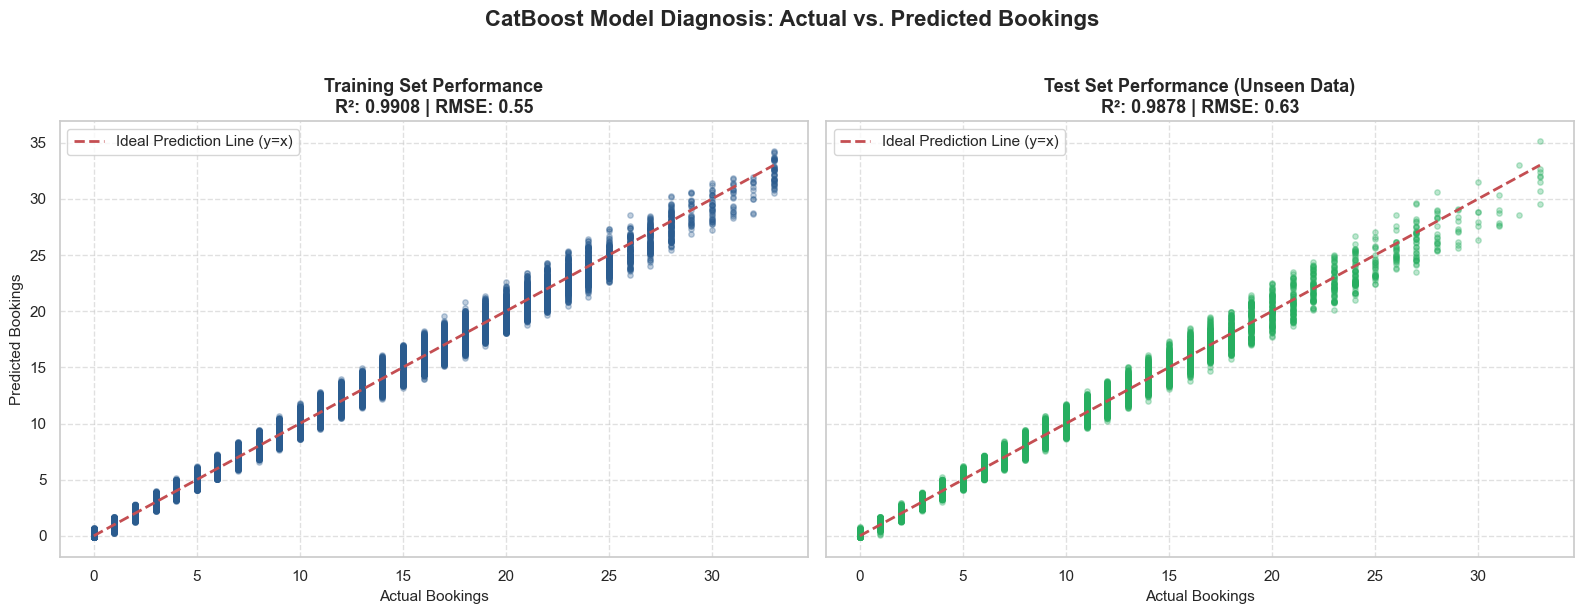

OVERFITTING DIAGNOSTIC SUMMARY
Train R²: 0.9908  |  Test R²: 0.9878
Train RMSE: 0.55  |  Test RMSE: 0.63

✅ SUCCESS: Model is WELL-BALANCED (R² gap is only 0.0030). Good generalization!


In [28]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# 1. Get predictions for BOTH Training and Test sets
catboost_model = best_models["CatBoost"]

y_train_pred = catboost_model.predict(X_train_scaled)
y_test_pred = catboost_model.predict(X_test_scaled)

# 2. Calculate metrics for comparison
r2_train = r2_score(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

r2_test = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

# 3. Create Side-by-Side Plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Subplot 1: Train Set
axes[0].scatter(y_train, y_train_pred, alpha=0.3, color="#2b5c8f", s=15)
axes[0].plot(
    [y_train.min(), y_train.max()],
    [y_train.min(), y_train.max()],
    "r--",
    lw=2,
    label="Ideal Prediction Line (y=x)",
)
axes[0].set_title(
    f"Training Set Performance\nR²: {r2_train:.4f} | RMSE: {rmse_train:.2f}",
    fontsize=13,
    fontweight="bold",
)
axes[0].set_xlabel("Actual Bookings", fontsize=11)
axes[0].set_ylabel("Predicted Bookings", fontsize=11)
axes[0].legend(loc="upper left")
axes[0].grid(True, linestyle="--", alpha=0.6)

# Subplot 2: Test Set
axes[1].scatter(y_test, y_test_pred, alpha=0.3, color="#27ae60", s=15)
axes[1].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    lw=2,
    label="Ideal Prediction Line (y=x)",
)
axes[1].set_title(
    f"Test Set Performance (Unseen Data)\nR²: {r2_test:.4f} | RMSE: {rmse_test:.2f}",
    fontsize=13,
    fontweight="bold",
)
axes[1].set_xlabel("Actual Bookings", fontsize=11)
axes[1].legend(loc="upper left")
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.suptitle(
    "CatBoost Model Diagnosis: Actual vs. Predicted Bookings",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

# 4. Print Overfitting Check
print("=" * 50)
print("OVERFITTING DIAGNOSTIC SUMMARY")
print("=" * 50)
print(f"Train R²: {r2_train:.4f}  |  Test R²: {r2_test:.4f}")
print(f"Train RMSE: {rmse_train:.2f}  |  Test RMSE: {rmse_test:.2f}")

r2_gap = r2_train - r2_test
if r2_gap > 0.05:
    print(
        f"\n⚠️ WARNING: Model may be OVERFITTING (R² gap is {r2_gap:.4f}). Consider increasing L2 regularization or reducing tree depth."
    )
else:
    print(
        f"\n✅ SUCCESS: Model is WELL-BALANCED (R² gap is only {r2_gap:.4f}). Good generalization!"
    )

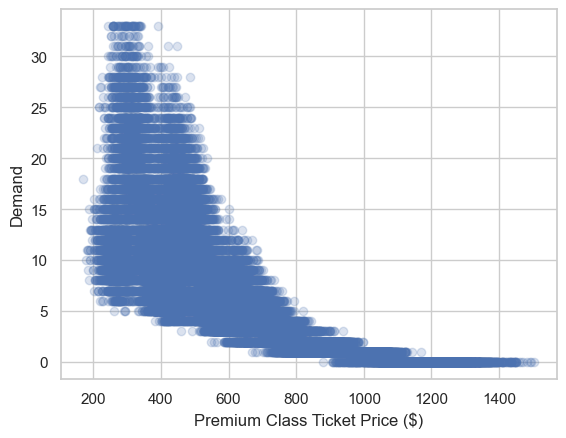

In [29]:
import matplotlib.pyplot as plt

plt.scatter(df["price"], 
            df["demand"], 
            alpha=0.2)

# Add axis labels and title
plt.xlabel("Premium Class Ticket Price ($)")
plt.ylabel("Demand")

plt.show()

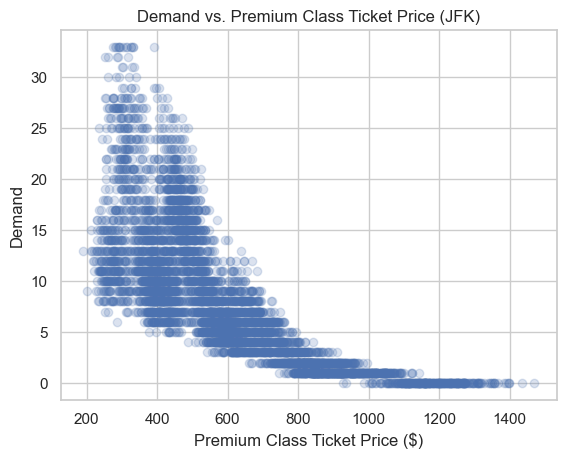

In [30]:
import matplotlib.pyplot as plt

# Filter DataFrame for destination "JFK"
jfk_df = df[df["destination"] == "JFK"]

plt.scatter(
    jfk_df["price"], 
    jfk_df["demand"], 
    alpha=0.2
)

# Add axis labels and title
plt.xlabel("Premium Class Ticket Price ($)")
plt.ylabel("Demand")
plt.title("Demand vs. Premium Class Ticket Price (JFK)")

plt.show()